In [1]:
import pandas as pd

df = pd.read_csv("../data/dataset_B_05_2020.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (11430, 89)


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["status"].value_counts())

Shape: (11430, 89)

Columns:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyperlinks', 'ratio_nullH

In [3]:
X = df.drop(columns=["status", "url"])
y = df["status"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11430, 87)
y shape: (11430,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (9144, 87)
X_test: (2286, 87)
y_train: (9144,)
y_test: (2286,)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", accuracy_lr)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8171478565179353

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.83      0.80      0.81      1143
    phishing       0.81      0.83      0.82      1143

    accuracy                           0.82      2286
   macro avg       0.82      0.82      0.82      2286
weighted avg       0.82      0.82      0.82      2286



c:\PhishingDetection\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [6]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9339457567804025

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.94      0.93      0.93      1143
    phishing       0.93      0.94      0.93      1143

    accuracy                           0.93      2286
   macro avg       0.93      0.93      0.93      2286
weighted avg       0.93      0.93      0.93      2286



In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9593175853018373

Classification Report:
              precision    recall  f1-score   support

  legitimate       0.96      0.95      0.96      1143
    phishing       0.95      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



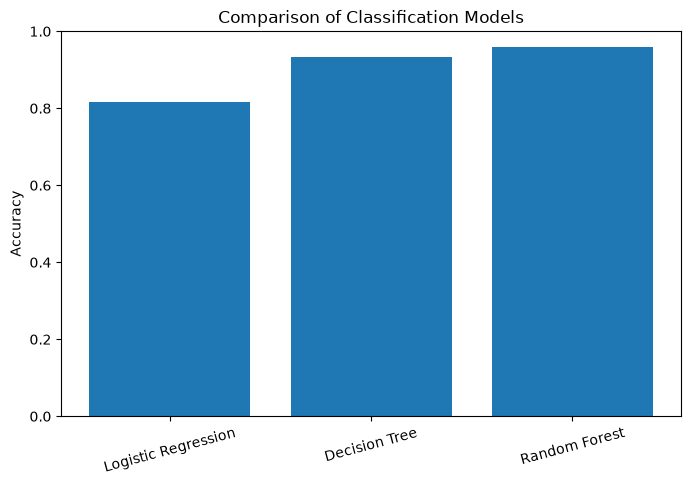

In [8]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracies = [accuracy_lr, accuracy_dt, accuracy_rf]

plt.figure(figsize=(8, 5))
plt.bar(models, accuracies)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Comparison of Classification Models")
plt.xticks(rotation=15)
plt.show()

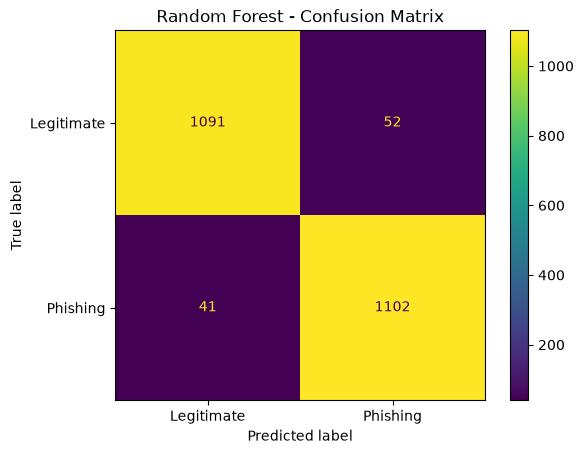

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Legitimate", "Phishing"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                Feature  Importance
85         google_index    0.180951
86            page_rank    0.098795
56        nb_hyperlinks    0.089064
83          web_traffic    0.073195
20               nb_www    0.041778
82           domain_age    0.033379
50          phish_hints    0.030850
58  ratio_extHyperlinks    0.028179
57  ratio_intHyperlinks    0.024976
74          safe_anchor    0.024517


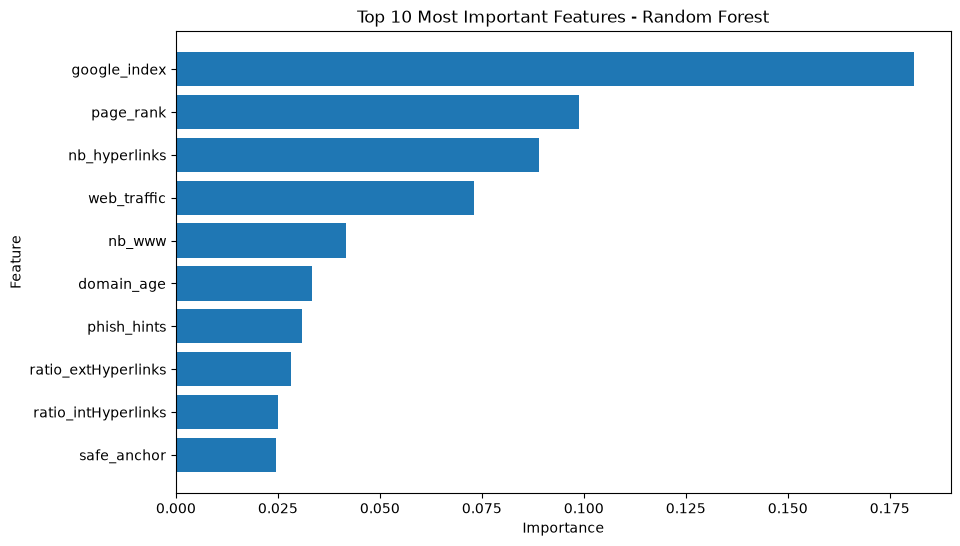

In [11]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [12]:
test_observation = X_test.iloc[[0]]

print("Observation index:", test_observation.index[0])

print("\nSelected features:")
print(test_observation[
    ["length_url", "length_hostname", "nb_dots", "nb_hyphens",
     "phish_hints", "domain_in_title", "google_index", "page_rank"]
])

Observation index: 6172

Selected features:
      length_url  length_hostname  nb_dots  nb_hyphens  phish_hints  \
6172          59               10        3           1            2   

      domain_in_title  google_index  page_rank  
6172                1             1          0  


In [13]:
prediction = rf_model.predict(test_observation)
probability = rf_model.predict_proba(test_observation).max()

print("Prediction:", prediction[0])
print("Probability:", f"{probability:.2%}")

Prediction: phishing
Probability: 97.00%


In [14]:
import joblib

joblib.dump(rf_model, "random_forest_phishing_model.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

print("Model and feature names saved successfully.")

Model and feature names saved successfully.
